In [3]:
import pandas as pd
df = pd.read_csv("/Users/luizaswierzawska1/Downloads/Data_ WHO Surveillance System for Attacks on Health Care (SSA) - Ukraine_Attacks.csv")
pd.set_option('display.max_columns', None)
df

,ID,REPORTID,LASTMODIFIED,ATTACKDATE,VERSIONID,ATTACKTIME,COUNTRY,COUNTRYISO2CODE,COUNTRYISO3CODE,ATTACKTIMESTAMP,CLASSIFICATIONID,CLASSIFICATION,ATTACKTYPE,ATTACKTYPEID,VICTIMSTOTALINJURED,VICTIMSTOTALDEATH,HCFACILITIES,HCTRANSPORT,HCPERSONNEL,HCSUPPLIESASSETS,HCWAREHOUSESTORAGE,HCPATIENTS,HCOTHER,TYPEOFFACILITY,FACILITYOTHER,HWABDUCTON,HWARREST,HWDETENTION,PATIENTABDUCTION,PATIENTARREST,PATIENTDETENTION
0,15111,UKR015111,2026-04-08 7:45:39,07/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-07 19:20:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,1,0,YES,YES,NO,Unknown,NO,YES,NaN,Secondary,Tertiary,0,0,0,0,0,0
1,15110,UKR015110,2026-04-08 7:44:02,04/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-04 19:10:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,0,0,YES,NO,NO,NO,NO,NO,NaN,Secondary,NaN,0,0,0,0,0,0
2,15109,UKR015109,2026-04-08 7:42:14,04/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-04 18:35:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,1,0,NO,NO,YES,NO,NO,NO,NaN,Other,Center of Emergency Care and Disaster Medicine,0,0,0,0,0,0
3,15085,UKR015085,2026-04-07 3:09:38,03/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-03 19:00:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,1,0,YES,NO,YES,NO,NO,NO,NaN,Secondary,NaN,0,0,0,0,0,0
4,15083,UKR015083,2026-04-07 3:09:27,02/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-02 18:30:15,4,Confirmed,Violence with heavy weapons (requires more th...,5,0,0,YES,NO,NO,Unknown,NO,NO,NaN,Primary,NaN,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2946,7624,UKR007624,2022-12-31 5:57:05,24/02/22,1,Time Unknown,Ukraine,UA,UKR,2022-02-24 14:55:45,4,Confirmed,Removal of health care assets (e.g. transport...,"2,5",0,0,YES,NO,NO,YES,NO,NO,NaN,Primary,NaN,0,0,0,0,0,0
2947,6354,UKR006354,2022-03-04 17:45:46,24/02/22,1,Time Unknown,Ukraine,UA,UKR,2022-02-24 14:25:30,2,Possible,"Unknown, Violence with individual weapons (kn...","13,4",0,0,NO,Unknown,NO,Unknown,NO,NO,NaN,NaN,NaN,0,0,0,0,0,0
2948,6353,UKR006353,2022-03-04 17:44:20,24/02/22,1,Time Unknown,Ukraine,UA,UKR,2022-02-24 14:10:30,2,Possible,Unknown,13,0,0,NO,Unknown,YES,Unknown,Unknown,Unknown,NaN,Primary,NaN,0,0,0,0,0,0
2949,6332,UKR006332,2022-02-25 5:14:07,24/02/22,1,11:00,Ukraine,UA,UKR,2022-02-24 11:00:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,10,4,YES,Unknown,YES,YES,Unknown,Unknown,NaN,Other,"both, primary and secondary",0,0,0,0,0,0


In [2]:
df.columns

Index(['ID', 'REPORTID', 'LASTMODIFIED', 'ATTACKDATE', 'VERSIONID',
       'ATTACKTIME', 'COUNTRY', 'COUNTRYISO2CODE', 'COUNTRYISO3CODE',
       'ATTACKTIMESTAMP', 'CLASSIFICATIONID', 'CLASSIFICATION', 'ATTACKTYPE',
       'ATTACKTYPEID', 'VICTIMSTOTALINJURED', 'VICTIMSTOTALDEATH',
       'HCFACILITIES', 'HCTRANSPORT', 'HCPERSONNEL', 'HCSUPPLIESASSETS',
       'HCWAREHOUSESTORAGE', 'HCPATIENTS', 'HCOTHER', 'TYPEOFFACILITY',
       'FACILITYOTHER', 'HWABDUCTON', 'HWARREST', 'HWDETENTION',
       'PATIENTABDUCTION', 'PATIENTARREST', 'PATIENTDETENTION'],
      dtype='object')

In [37]:
df["Date"] = pd.to_datetime(df["ATTACKDATE"], format="%d/%m/%y").dt.to_period('M')

In [53]:
# Number of attacks per month
attacks_per_month = df["Date"].value_counts(sort=False).sort_values(ascending=False).reset_index()

In [60]:
attacks_per_month["Date"] = attacks_per_month["Date"].dt.to_timestamp()
attacks_per_month

,Date,count
0,2022-03-01,464
1,2022-04-01,165
2,2022-09-01,140
3,2022-07-01,103
4,2022-05-01,100
5,2022-06-01,90
6,2022-10-01,81
7,2022-08-01,73
8,2025-07-01,72
9,2024-09-01,64


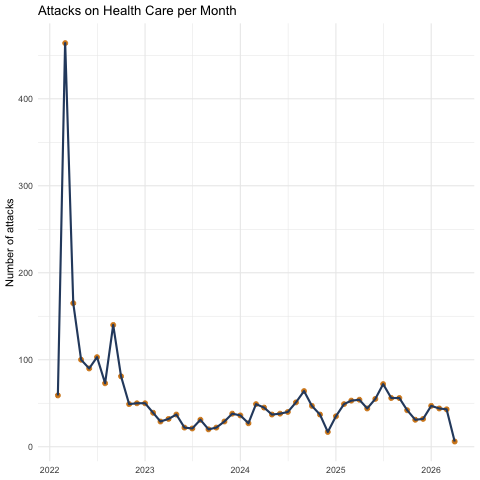

In [61]:
%%R -i attacks_per_month

ggplot(attacks_per_month, aes(x = Date, y = count)) +
  geom_point(color = "#D4861A", size = 2) +
  geom_line(color = "#2C4A6E", linewidth = 1) +
  theme_minimal() +
  labs(
    title = "Attacks on Health Care per Month",
    x = NULL,
    y = "Number of attacks"
  )

In [ ]:
# Number of attacks per year
df["Year"].value_counts()

Year
2022    1374
2025     579
2024     488
2023     370
2026     140
Name: count, dtype: int64

In [11]:
print(df["ATTACKTYPE"].value_counts())


ATTACKTYPE
 Violence with heavy weapons (requires more than one person to use such as firearms, tanks, missiles, bombs, mortars)                                                                                                                                                                                                                                                                                                                2578
 Removal of health care assets (e.g. transport, supplies, materials)                                                                                                                                                                                                                                                                                                                                                                  117
 Removal of health care assets (e.g. transport, supplies, materials), Violence with heavy weapons (requires more than one person to use s

In [16]:
import re
attack_counts = df["ATTACKTYPE"].apply(lambda x: re.split(r',\s*(?=[A-Z])', x)).explode().str.strip().value_counts().reset_index()
attack_counts.columns = ["attack_type", "count"]

In [ ]:
attack_counts

,attack_type,count
0,Violence with heavy weapons (requires more tha...,2655
1,"Removal of health care assets (e.g. transport,...",225
2,Militarization of a health care asset,103
3,"Violence with individual weapons (knives, bric...",70
4,Psychological violence/threat of violence/inti...,60
5,Obstruction to health care delivery (e.g. phys...,56
6,Unknown,40
7,Armed or violent search of health care personn...,19
8,Abduction/Arrest/Detention of health personnel...,19
9,Assault (without weapons),4


In [19]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML



Error importing in API mode: ImportError("dlopen(/Users/luizaswierzawska1/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/luizaswierzawska1/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [23]:
%%R

require('tidyverse')
require('ggplot2')

In [30]:
%%R -i attack_counts

## Treemap with attack counts

install.packages("treemapify")
require("treemapify")

ggplot(attack_counts, aes(
    area = count,
    fill = attack_type,
    label = paste(attack_type, count, sep = "\n")
  )) +
  geom_treemap() +
  geom_treemap_text(
    colour = "white",
    place = "topleft",
    fontface = "bold",
    size = 10,
    grow = FALSE,
    reflow = TRUE,
    overflow = "hide"
  ) +
  scale_fill_manual(values = c(
    "#D4861A", "#2C4A6E", "#3D6B8E",
    "#5A7F9E", "#8AAFC4", "#1C2B3A",
    "#C9A84C", "#8AAFC4", "#8AAFC4", 
    "#8AAFC4", "#8AAFC4", "#8AAFC4"
  )) +
  theme(legend.position = "none")

  ggsave("treemap.svg")

* installing *source* package ‘treemapify’ ...
** this is package ‘treemapify’ version ‘2.6.0’
** package ‘treemapify’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** data
*** moving datasets to lazyload DB
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (treemapify)


Saving 6.67 x 6.67 in image


Installing package into ‘/opt/homebrew/lib/R/4.5/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://mirror.chpc.utah.edu/pub/cran/src/contrib/treemapify_2.6.0.tar.gz'
Content type 'application/x-gzip' length 4422360 bytes (4.2 MB)
downloaded 4.2 MB


The downloaded source packages are in
	‘/private/var/folders/3w/05xwp7qj761gvqj6rcry6n700000gp/T/RtmpZwSanh/downloaded_packages’
In addition: Warning message:
In geom_treemap_text(colour = "white", place = "topleft", fontface = "bold",  :
  Ignoring unknown parameters: `overflow`
